<a href="https://colab.research.google.com/github/mhmdaman/tweets/blob/main/twitter_bot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()  # select training_data_2_csv_UTF.csv when prompted

Saving training_data_2_csv_UTF .csv to training_data_2_csv_UTF  (1).csv


In [ ]:
import pandas as pd
import json
import re
import ast
import os

# Auto-detect the CSV filename fresh, every time this cell runs
RAW_PATH = [f for f in os.listdir() if f.endswith(".csv") and "sample_data" not in f][0]
print("Using file:", RAW_PATH)

def extract_tweet_text(raw_status):
    if pd.isna(raw_status):
        return ""
    try:
        data = ast.literal_eval(raw_status)
        if isinstance(data, dict) and data.get("text"):
            return data["text"]
    except Exception:
        pass
    try:
        data = json.loads(raw_status)
        if isinstance(data, dict) and data.get("text"):
            return data["text"]
    except Exception:
        pass
    match = re.search(r'"text"\s*:\s*"(.*?)",\s*\r?\s*"truncated"', raw_status, re.DOTALL)
    if match:
        return match.group(1)
    match = re.search(r"'text'\s*:\s*'(.*?)',\s*\r?\s*'truncated'", raw_status, re.DOTALL)
    if match:
        return match.group(1)
    return ""

def clean_text(text):
    if not isinstance(text, str):
        return text
    return text.encode("utf-8", "ignore").decode("utf-8")

df = pd.read_csv(RAW_PATH, engine="python", on_bad_lines="skip")
df["tweet_text"] = df["status"].apply(extract_tweet_text).apply(clean_text)

keep_cols = [
    "id", "screen_name", "location", "description", "url",
    "followers_count", "friends_count", "listed_count", "created_at",
    "favourites_count", "verified", "statuses_count", "lang",
    "default_profile", "default_profile_image", "has_extended_profile",
    "name", "tweet_text", "bot",
]
df = df[keep_cols]
print(df.shape)
print(df["bot"].value_counts())
df.head()

Using file: training_data_2_csv_UTF  (1).csv
(2797, 19)
bot
0    1476
1    1321
Name: count, dtype: int64


,id,screen_name,location,description,url,followers_count,friends_count,listed_count,created_at,favourites_count,verified,statuses_count,lang,default_profile,default_profile_image,has_extended_profile,name,tweet_text,bot
0,8.160000e+17,"""HoustonPokeMap""","""Houston, TX""","""Rare and strong PokŽmon in Houston, TX. See m...","""https://t.co/dnWuDbFRkt""",1291,0,10,"""Mon Jan 02 02:25:26 +0000 2017""",0,False,78554,"""en""",True,False,False,"""Houston PokŽ Alert""",[Southeast Houston] Chansey (F) (IV: 73%) unti...,1
1,4.843621e+09,kernyeahx,"Templeville town, MD, USA",From late 2014 Socium Marketplace will make sh...,NaN,1,349,0,2/1/2016 7:37,38,False,31,en,True,False,False,Keri Nelson,,1
2,4.303727e+09,mattlieberisbot,NaN,"Inspired by the smart, funny folks at @replyal...",https://t.co/P1e1o0m4KC,1086,0,14,Fri Nov 20 18:53:22 +0000 2015,0,False,713,en,True,False,False,Matt Lieber Is Bot,Matt Lieber is a little bit of hot supper afte...,1
3,3.063139e+09,sc_papers,NaN,NaN,NaN,33,0,8,2/25/2015 20:11,0,False,676,en,True,True,False,single cell papers,,1
4,2.955142e+09,lucarivera16,"Dublin, United States",Inspiring cooks everywhere since 1956.,NaN,11,745,0,1/1/2015 17:44,146,False,185,en,False,False,False,lucarivera16,,1


In [ ]:
import numpy as np

# Account age in days (from created_at to a fixed reference date, since
# these accounts were scraped years ago — using "now" would be misleading)
df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce", utc=True)
reference_date = df["created_at"].max()
df["account_age_days"] = (reference_date - df["created_at"]).dt.days
df["account_age_days"] = df["account_age_days"].fillna(df["account_age_days"].median())

# Ratio features
df["follower_friend_ratio"] = df["followers_count"] / (df["friends_count"] + 1)
df["tweets_per_day"] = df["statuses_count"] / (df["account_age_days"] + 1)
df["favourites_per_day"] = df["favourites_count"] / (df["account_age_days"] + 1)

# Username / name signals
df["screen_name_len"] = df["screen_name"].astype(str).str.len()
df["screen_name_digit_ratio"] = df["screen_name"].astype(str).apply(
    lambda s: sum(c.isdigit() for c in s) / max(len(s), 1)
)
df["name_len"] = df["name"].astype(str).str.len()

# Presence flags for optional fields (missingness itself can be signal)
df["has_location"] = df["location"].notna().astype(int)
df["has_description"] = df["description"].notna().astype(int)
df["has_url"] = df["url"].notna().astype(int)
df["has_tweet_text"] = (df["tweet_text"].fillna("").str.strip() != "").astype(int)

# Description length
df["description_len"] = df["description"].fillna("").str.len()

# Boolean-like columns -> proper 0/1
for col in ["verified", "default_profile", "default_profile_image", "has_extended_profile"]:
    df[col] = df[col].map({True: 1, False: 0, "TRUE": 1, "FALSE": 0}).fillna(0).astype(int)

df.head()

/tmp/ipykernel_3107/564891483.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce", utc=True)


,id,screen_name,location,description,url,followers_count,friends_count,listed_count,created_at,favourites_count,...,tweets_per_day,favourites_per_day,screen_name_len,screen_name_digit_ratio,name_len,has_location,has_description,has_url,has_tweet_text,description_len
0,8.160000e+17,"""HoustonPokeMap""","""Houston, TX""","""Rare and strong PokŽmon in Houston, TX. See m...","""https://t.co/dnWuDbFRkt""",1291,0,10,NaT,0,...,51.443353,0.000000,16,0.000000,20,1,1,1,1,85
1,4.843621e+09,kernyeahx,"Templeville town, MD, USA",From late 2014 Socium Marketplace will make sh...,NaN,1,349,0,2016-02-01 07:37:00+00:00,38,...,0.046131,0.056548,9,0.000000,11,1,1,0,0,139
2,4.303727e+09,mattlieberisbot,NaN,"Inspired by the smart, funny folks at @replyal...",https://t.co/P1e1o0m4KC,1086,0,14,2015-11-20 18:53:22+00:00,0,...,0.957047,0.000000,15,0.000000,18,0,1,1,1,124
3,3.063139e+09,sc_papers,NaN,NaN,NaN,33,0,8,2015-02-25 20:11:00+00:00,0,...,0.667984,0.000000,9,0.000000,18,0,0,0,0,0
4,2.955142e+09,lucarivera16,"Dublin, United States",Inspiring cooks everywhere since 1956.,NaN,11,745,0,2015-01-01 17:44:00+00:00,146,...,0.173221,0.136704,12,0.166667,12,1,1,0,0,38


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Fill NaN values in 'tweet_text' with empty strings before TF-IDF
df['tweet_text'] = df['tweet_text'].fillna('')

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting features to avoid very high dimensionality

# Fit and transform the tweet_text data
tfidf_matrix = tfidf_vectorizer.fit_transform(df['tweet_text'])

# Convert the TF-IDF matrix to a DataFrame
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

print("TF-IDF features shape:", tfidf_df.shape)
display(tfidf_df.head())

TF-IDF features shape: (2797, 5000)


,00,000,0000,001000,008,009,00____________________________________________________________8______________,01,0111011001110001010111,011187,...,ꑪ𝖎غﲧᜄฟഫ𝕺神,ꙟ𝘍,ꤐኁﺁ𓀷ﲁળ𒅂諒ਉ,ｃｙｂｅｒｋｏｎａｒｉｏｔ,ｆｌａｔｔｅｒａｂｌｅ,ｋｏ,ｓｈｏａｄ,ｲ𖨙ᵮძ,𐑉घꋦꛃꊝ𖣍,𒀆𖠆
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
metadata_features = [
    "followers_count", "friends_count", "listed_count", "favourites_count",
    "statuses_count", "verified", "default_profile", "default_profile_image",
    "has_extended_profile", "account_age_days", "follower_friend_ratio",
    "tweets_per_day", "favourites_per_day", "screen_name_len",
    "screen_name_digit_ratio", "name_len", "has_location",
    "has_description", "has_url", "has_tweet_text", "description_len",
]

X_metadata = df[metadata_features].copy()
y = df["bot"]

X_hybrid = pd.concat([X_metadata.reset_index(drop=True), tfidf_df.reset_index(drop=True)], axis=1)

print("Metadata-only shape:", X_metadata.shape)
print("Hybrid shape:", X_hybrid.shape)

Metadata-only shape: (2797, 21)
Hybrid shape: (2797, 5021)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

def prepare_split(X, y, test_size=0.3, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    sm = SMOTE(random_state=random_state)
    X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

    return X_train_res, X_test_scaled, y_train_res, y_test, scaler

# Metadata-only split (baseline) — 70% train / 30% test
Xm_train, Xm_test, ym_train, ym_test, scaler_meta = prepare_split(X_metadata, y)

# Hybrid split (metadata + TF-IDF) — 70% train / 30% test
Xh_train, Xh_test, yh_train, yh_test, scaler_hybrid = prepare_split(X_hybrid, y)

print("Metadata train (post-SMOTE):", Xm_train.shape, "class balance:", np.bincount(ym_train))
print("Metadata test:", Xm_test.shape)
print("Hybrid train (post-SMOTE):", Xh_train.shape, "class balance:", np.bincount(yh_train))
print("Hybrid test:", Xh_test.shape)

Metadata train (post-SMOTE): (2066, 21) class balance: [1033 1033]
Metadata test: (840, 21)
Hybrid train (post-SMOTE): (2066, 5021) class balance: [1033 1033]
Hybrid test: (840, 5021)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

def train_models(X_train, y_train):
    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
        "SVM": SVC(kernel="rbf", probability=True, random_state=42),
    }
    fitted = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        fitted[name] = model
        print(f"Trained: {name}")
    return fitted

print("=== Baseline (metadata only) ===")
models_meta = train_models(Xm_train, ym_train)

print("\n=== Hybrid (metadata + TF-IDF) ===")
models_hybrid = train_models(Xh_train, yh_train)

=== Baseline (metadata only) ===
Trained: Logistic Regression
Trained: Random Forest
Trained: SVM

=== Hybrid (metadata + TF-IDF) ===
Trained: Logistic Regression
Trained: Random Forest
Trained: SVM


In [ ]:
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, f1_score
)

def evaluate(models, X_test, y_test, label):
    print(f"\n{'='*20} {label} {'='*20}")
    results = []
    for name, model in models.items():
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

        print(f"\n--- {name} ---")
        print(classification_report(y_test, y_pred, target_names=["human", "bot"]))
        cm = confusion_matrix(y_test, y_pred)
        print("Confusion matrix:\n", cm)

        auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None
        f1 = f1_score(y_test, y_pred)
        results.append({"model": name, "f1": f1, "roc_auc": auc})
    return pd.DataFrame(results)

results_meta = evaluate(models_meta, Xm_test, ym_test, "Baseline: Metadata Only")
results_hybrid = evaluate(models_hybrid, Xh_test, yh_test, "Hybrid: Metadata + TF-IDF")

print("\n\nSummary — Baseline vs Hybrid")
print(results_meta)
print(results_hybrid)


==================== Baseline: Metadata Only ====================

--- Logistic Regression ---
              precision    recall  f1-score   support

       human       0.92      0.83      0.87       443
         bot       0.83      0.92      0.87       397

    accuracy                           0.87       840
   macro avg       0.88      0.88      0.87       840
weighted avg       0.88      0.87      0.87       840

Confusion matrix:
 [[369  74]
 [ 32 365]]

--- Random Forest ---
              precision    recall  f1-score   support

       human       0.90      0.92      0.91       443
         bot       0.91      0.89      0.90       397

    accuracy                           0.91       840
   macro avg       0.91      0.91      0.91       840
weighted avg       0.91      0.91      0.91       840

Confusion matrix:
 [[409  34]
 [ 43 354]]

--- SVM ---
              precision    recall  f1-score   support

       human       0.92      0.84      0.88       443
         bot       0.

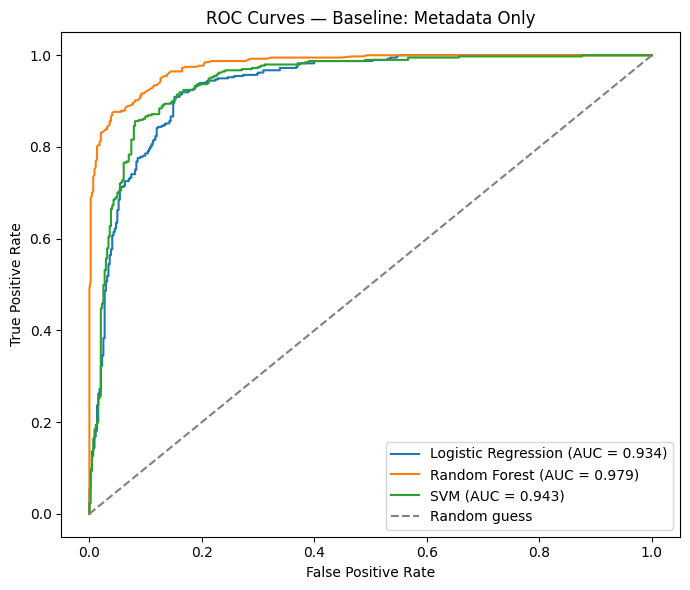

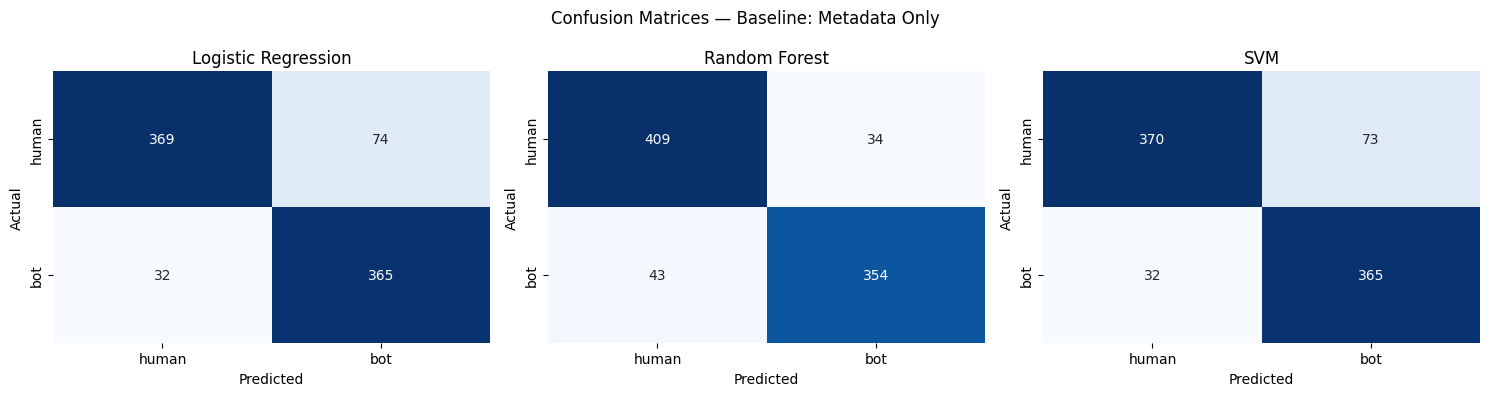

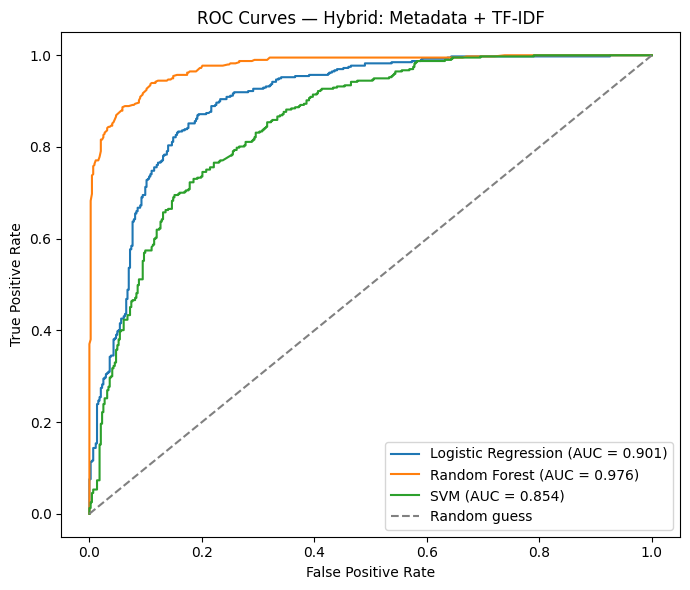

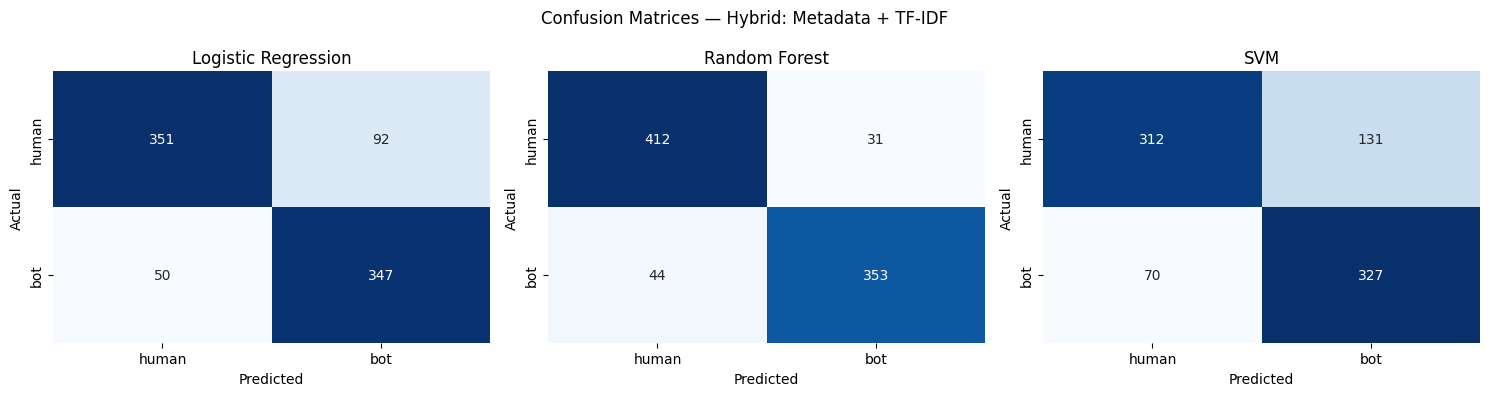

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix

def plot_roc_curves(models, X_test, y_test, title):
    plt.figure(figsize=(7, 6))
    for name, model in models.items():
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test)[:, 1]
        else:
            y_proba = model.decision_function(X_test)

        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves — {title}")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


def plot_confusion_matrices(models, X_test, y_test, title):
    n = len(models)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]

    for ax, (name, model) in zip(axes, models.items()):
        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(
            cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
            xticklabels=["human", "bot"], yticklabels=["human", "bot"],
        )
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.set_title(name)

    fig.suptitle(f"Confusion Matrices — {title}")
    plt.tight_layout()
    plt.show()


# Baseline (metadata only)
plot_roc_curves(models_meta, Xm_test, ym_test, "Baseline: Metadata Only")
plot_confusion_matrices(models_meta, Xm_test, ym_test, "Baseline: Metadata Only")

# Hybrid (metadata + TF-IDF)
plot_roc_curves(models_hybrid, Xh_test, yh_test, "Hybrid: Metadata + TF-IDF")
plot_confusion_matrices(models_hybrid, Xh_test, yh_test, "Hybrid: Metadata + TF-IDF")

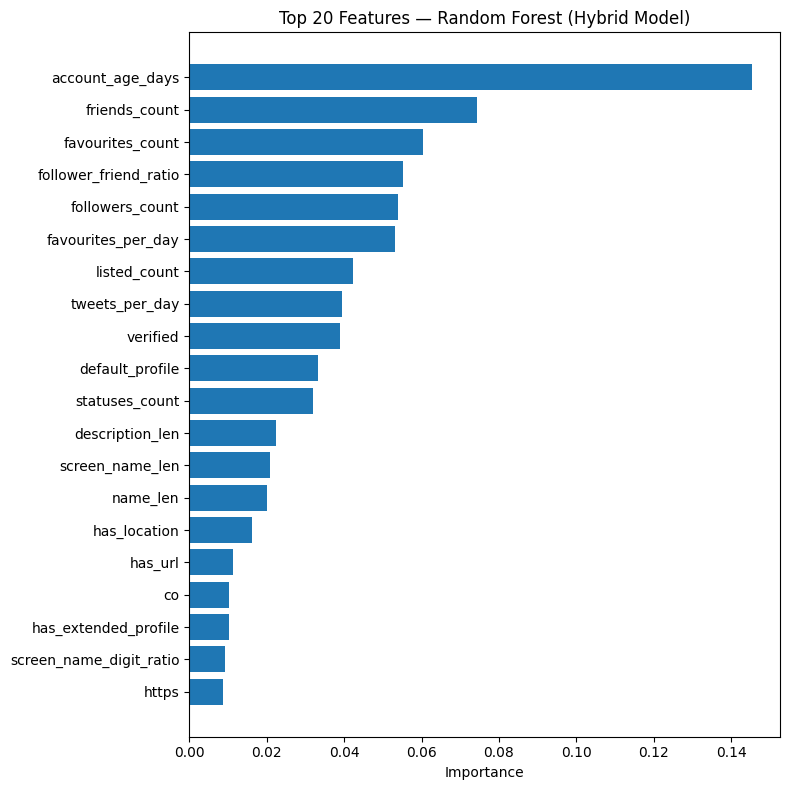

In [ ]:
import matplotlib.pyplot as plt

rf_hybrid = models_hybrid["Random Forest"]
feature_names = X_hybrid.columns
importances = rf_hybrid.feature_importances_

top_idx = np.argsort(importances)[-20:]
plt.figure(figsize=(8, 8))
plt.barh(range(len(top_idx)), importances[top_idx])
plt.yticks(range(len(top_idx)), [feature_names[i] for i in top_idx])
plt.xlabel("Importance")
plt.title("Top 20 Features — Random Forest (Hybrid Model)")
plt.tight_layout()
plt.show()

In [ ]:
import random

def show_test_prediction(index, X_test_scaled, X_test_raw, y_test, model, model_name):
    """Pick one row from the test set, show its actual features, the true
    label, and the model's prediction side by side."""
    true_label = y_test.iloc[index]
    features_row = X_test_scaled[index].reshape(1, -1)

    pred = model.predict(features_row)[0]
    proba = model.predict_proba(features_row)[0][1] if hasattr(model, "predict_proba") else None

    raw_row = X_test_raw.iloc[index]

    print(f"--- Test account #{X_test_raw.index[index]} ---")
    print(f"Followers: {raw_row['followers_count']}, Friends: {raw_row['friends_count']}, "
          f"Account age (days): {raw_row['account_age_days']:.0f}, "
          f"Tweets/day: {raw_row['tweets_per_day']:.2f}")
    print(f"Verified: {bool(raw_row['verified'])}, Default profile image: {bool(raw_row['default_profile_image'])}")
    print()
    print(f"TRUE label:      {'BOT' if true_label == 1 else 'HUMAN'}")
    print(f"Model prediction: {'BOT' if pred == 1 else 'HUMAN'}", end="")
    if proba is not None:
        print(f"  (bot probability: {proba:.2%})")
    else:
        print()
    print(f"Correct: {'✅' if pred == true_label else '❌'}")
    print()


# Reconstruct the raw (unscaled) test rows for readable display
_, Xm_test_raw, _, _ = train_test_split(
    X_metadata, y, test_size=0.3, stratify=y, random_state=42
)

model_to_test = models_meta["Random Forest"]  # change to models_hybrid[...] to test the hybrid model

# Show a few random examples
random.seed(1)
sample_indices = random.sample(range(len(ym_test)), 5)

for idx in sample_indices:
    show_test_prediction(idx, Xm_test, Xm_test_raw, ym_test, model_to_test, "Random Forest")
    print("=" * 60)

--- Test account #2199 ---
Followers: 443.0, Friends: 497.0, Account age (days): 316, Tweets/day: 3.79
Verified: False, Default profile image: False

TRUE label:      HUMAN
Model prediction: HUMAN  (bot probability: 17.67%)
Correct: ✅

--- Test account #1522 ---
Followers: 41.0, Friends: 290.0, Account age (days): 271, Tweets/day: 0.01
Verified: False, Default profile image: False

TRUE label:      HUMAN
Model prediction: HUMAN  (bot probability: 38.50%)
Correct: ✅

--- Test account #2673 ---
Followers: 495530.0, Friends: 2155.0, Account age (days): 3141, Tweets/day: 1.38
Verified: True, Default profile image: False

TRUE label:      HUMAN
Model prediction: HUMAN  (bot probability: 0.00%)
Correct: ✅

--- Test account #587 ---
Followers: 1.0, Friends: 258.0, Account age (days): 312, Tweets/day: 0.04
Verified: False, Default profile image: False

TRUE label:      BOT
Model prediction: BOT  (bot probability: 98.50%)
Correct: ✅

--- Test account #453 ---
Followers: 98.0, Friends: 274.0, Ac

In [ ]:
def predict_account(
    followers_count, friends_count, listed_count, favourites_count,
    statuses_count, verified, default_profile, default_profile_image,
    has_extended_profile, account_age_days, screen_name, name,
    location, description, url, tweet_text, model=None, use_hybrid=True
):
    follower_friend_ratio = followers_count / (friends_count + 1)
    tweets_per_day = statuses_count / (account_age_days + 1)
    favourites_per_day = favourites_count / (account_age_days + 1)
    screen_name_len = len(str(screen_name))
    screen_name_digit_ratio = sum(c.isdigit() for c in str(screen_name)) / max(len(str(screen_name)), 1)
    name_len = len(str(name))
    has_location = int(bool(location))
    has_description = int(bool(description))
    has_url = int(bool(url))
    has_tweet_text = int(bool(tweet_text and tweet_text.strip()))
    description_len = len(str(description)) if description else 0

    row = {
        "followers_count": followers_count,
        "friends_count": friends_count,
        "listed_count": listed_count,
        "favourites_count": favourites_count,
        "statuses_count": statuses_count,
        "verified": int(verified),
        "default_profile": int(default_profile),
        "default_profile_image": int(default_profile_image),
        "has_extended_profile": int(has_extended_profile),
        "account_age_days": account_age_days,
        "follower_friend_ratio": follower_friend_ratio,
        "tweets_per_day": tweets_per_day,
        "favourites_per_day": favourites_per_day,
        "screen_name_len": screen_name_len,
        "screen_name_digit_ratio": screen_name_digit_ratio,
        "name_len": name_len,
        "has_location": has_location,
        "has_description": has_description,
        "has_url": has_url,
        "has_tweet_text": has_tweet_text,
        "description_len": description_len,
    }

    input_meta = pd.DataFrame([row])[metadata_features]

    if use_hybrid:
        # Uses YOUR variable name: tfidf_vectorizer, and no "tfidf_" column prefix
        tweet_vec = tfidf_vectorizer.transform([tweet_text if tweet_text else ""])
        tweet_df = pd.DataFrame(
            tweet_vec.toarray(),
            columns=tfidf_vectorizer.get_feature_names_out(),
        )
        input_full = pd.concat([input_meta.reset_index(drop=True), tweet_df], axis=1)
        input_scaled = scaler_hybrid.transform(input_full)
        model = model or models_hybrid["Random Forest"]
    else:
        input_scaled = scaler_meta.transform(input_meta)
        model = model or models_meta["Random Forest"]

    pred = model.predict(input_scaled)[0]
    proba = model.predict_proba(input_scaled)[0][1] if hasattr(model, "predict_proba") else None

    label = "BOT" if pred == 1 else "HUMAN"
    print(f"Prediction: {label}")
    if proba is not None:
        print(f"Bot probability: {proba:.2%}")
    return pred, proba

In [ ]:
!pip install requests -q

In [ ]:
import requests
import re
from datetime import datetime, timezone
from google.colab import userdata

TWITTERAPI_IO_KEY = userdata.get('TWITTERAPI_IO_KEY')

BASE_URL = "https://api.twitterapi.io"
HEADERS = {"X-API-Key": TWITTERAPI_IO_KEY}


def extract_username(link_or_handle):
    link_or_handle = link_or_handle.strip()
    match = re.search(r"(?:x\.com|twitter\.com)/([A-Za-z0-9_]+)", link_or_handle)
    if match:
        return match.group(1)
    return link_or_handle.lstrip("@")


def parse_created_at(created_at_str):
    """Handles multiple possible date formats returned by the API."""
    if not created_at_str:
        return 0

    for fmt in (
        "%Y-%m-%dT%H:%M:%S.%fZ",       # e.g. 2025-07-01T14:36:34.000000Z
        "%a %b %d %H:%M:%S %z %Y",     # classic Twitter format
        "%Y-%m-%dT%H:%M:%SZ",          # ISO without microseconds
    ):
        try:
            created_dt = datetime.strptime(created_at_str, fmt)
            if created_dt.tzinfo is None:
                created_dt = created_dt.replace(tzinfo=timezone.utc)
            return (datetime.now(timezone.utc) - created_dt).days
        except ValueError:
            continue

    print(f"Warning: could not parse createdAt='{created_at_str}'")
    return 0


def fetch_account_data(link_or_handle):
    username = extract_username(link_or_handle)

    resp = requests.get(f"{BASE_URL}/twitter/user/info", headers=HEADERS,
                         params={"userName": username})
    resp.raise_for_status()
    payload = resp.json()

    if payload.get("status") != "success" or "data" not in payload:
        raise ValueError(f"Could not fetch account '{username}': {payload.get('msg')}")

    user = payload["data"]

    tweet_text = ""
    tweets_resp = requests.get(f"{BASE_URL}/twitter/user/last_tweets", headers=HEADERS,
                                params={"userName": username})
    if tweets_resp.status_code == 200:
        tweets_payload = tweets_resp.json()
        tweets_list = (
            tweets_payload.get("data", {}).get("tweets")
            or tweets_payload.get("tweets")
            or []
        )
        if tweets_list:
            tweet_text = tweets_list[0].get("text", "")

    account_age_days = parse_created_at(user.get("createdAt", ""))

    return {
        "followers_count": user.get("followers", 0),
        "friends_count": user.get("following", 0),
        "listed_count": 0,
        "favourites_count": user.get("favouritesCount", 0),
        "statuses_count": user.get("statusesCount", 0),
        "verified": bool(user.get("isBlueVerified", False)),
        "default_profile": False,
        "default_profile_image": "default_profile" in (user.get("profilePicture") or ""),
        "has_extended_profile": bool(user.get("description")),
        "account_age_days": account_age_days,
        "screen_name": user.get("userName", username),
        "name": user.get("name", ""),
        "location": user.get("location", "") or "",
        "description": user.get("description", "") or "",
        "url": user.get("url", "") or "",
        "tweet_text": tweet_text,
    }


def predict_from_link(link_or_handle, model=None, use_hybrid=True):
    data = fetch_account_data(link_or_handle)
    print(f"Fetched: @{data['screen_name']} — {data['followers_count']:,} followers, "
          f"{data['statuses_count']:,} tweets, account age {data['account_age_days']} days\n")
    return predict_account(**data, model=model, use_hybrid=use_hybrid)

In [50]:
def predict_from_link(link_or_handle, model=None, use_hybrid=True):
    data = fetch_account_data(link_or_handle)
    print(f"Fetched: @{data['screen_name']} — {data['followers_count']:,} followers, "
          f"{data['statuses_count']:,} tweets, account age {data['account_age_days']} days\n")
    return predict_account(**data, model=model, use_hybrid=use_hybrid)

predict_from_link("https://x.com/BeingSalmanKhan")

Fetched: @BeingSalmanKhan — 42,199,939 followers, 43,566 tweets, account age 5981 days

Prediction: HUMAN
Bot probability: 24.00%


(np.int64(0), np.float64(0.24))